# Modeling Light Echo Evolution

In this tutorial, we will demonstate the creation of the of light echoes (LEs) from an astrophysical transient (e.g., a supernova). These simulations help us predict how Rubin LSST will detect light echoes for historical transients in our Milky Way and nearby galaxies.

To keep the exercise simple, we assume:
- Brightness of LEs is proportional to local dust density (from a 2D dust map);

- Distances between the source and dust are computed as Euclidean distances in 2D (not full 3D geometry).

Key equation:

$F_{LE} = a_{dust} * F_{model} (t + \Delta T) + F_{background}$

Workflow

- load a supernova light curve and create a model
- load dust image from Spitzer telescope; normalize dust intensity to represent the scattering effect;
- compute phase difference dT based on distances to the source
- create echo image
- make an animation
- extract light curves at a fixed point: pick a position and track its brightness over time
- explore how the appearance of the LEs changes for short and long transients


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
# change path
%cd /content/drive/MyDrive/ztf_summer_school_2026/day3/le_study/

/content/drive/MyDrive/ztf_summer_school_2026/day3/le_study


In [ ]:
import os
import glob
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import astropy
from astropy.io import fits
import astropy.wcs
from astropy import units as u
from astropy.coordinates import SkyCoord


In [ ]:
!pip install reproject


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.4/193.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 86.2 MB/s eta 0:00:00
  Created wheel for pims: filename=PIMS-0.7-py3-none-any.whl size=84590 sha256=83216353559ac9793e531cdd94a74229b442d815f7390671cb4eb27da4f92edd
  Stored in directory: /root/.cache/pip/wheels/be/9c/72/7cb84823aaa980c2e44064caae0ba869239270fac14f7129aa
Successfully built pims


In [ ]:
from reproject import reproject_interp
# used to reproject image between different coordinates system

In [ ]:
# load fits image
def get_imgarr(fitsfile, idx=0, return_header=False):
    """get image array from fits
    Parameters:
        fitsfile: FITS file
        idx: hdul index in FITS
        return_header: boolean, return FITS header
    """
    from astropy.io import fits
    hdul = fits.open(fitsfile)
    item = hdul[idx]
    if item.is_image:
        header = item.header
        # invert y to be same as jpg
        #imgarr = item.data[::-1, :]
        imgarr = item.data
        hdul.close()
        if return_header:
            return imgarr, header
        else:
            return imgarr
    else:
        print('not image file')


## load model

load a supernova light curve and create a model

In [ ]:
#df_lc = pd.read_csv('2013ab_phot.txt', skiprows=2)
df_lc = pd.read_csv('dataset/LEsim/2014J_phot.txt', skiprows=2)

In [ ]:
df_lc

,# FLT,MJD,MAG,MAGERR
0,R,56677.684437,11.393259,0.01
1,R,56678.312051,11.005618,0.01
2,B,56678.869000,12.966000,0.01
3,V,56678.869000,11.721000,0.01
4,I,56678.870000,10.626000,0.01
...,...,...,...,...
774,V,56785.800000,13.829000,0.01
775,B,56798.900000,15.571000,0.01
776,I,56798.900000,13.078000,0.01
777,R,56798.900000,13.545000,0.01


In [ ]:
# convert mag to flux
def mag2flux(m, m0):
    return 10**(-0.4 * (m - m0))


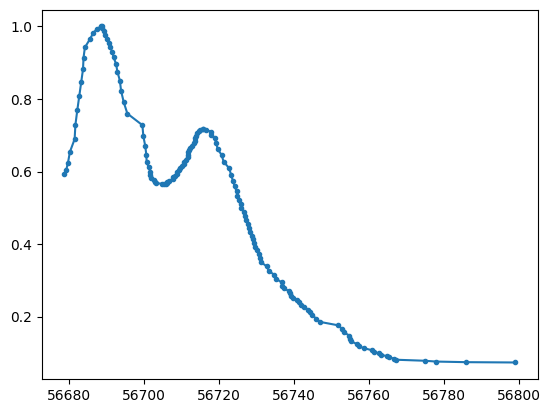

In [ ]:
x = df_lc [df_lc['# FLT'] == 'I']['MJD']
y = df_lc [df_lc['# FLT'] == 'I']['MAG']

y = mag2flux(y, 8.9)

y = sp.ndimage.gaussian_filter1d(y, 4, output=y)

# normalize flux

y = y/np.max(y)

plt.plot(x, y, '.-')

#plt.gca().invert_yaxis()


In [ ]:
lc = sp.interpolate.interp1d(x, y, kind='linear', bounds_error=False, fill_value=0)


Text(0, 0.5, 'flux')

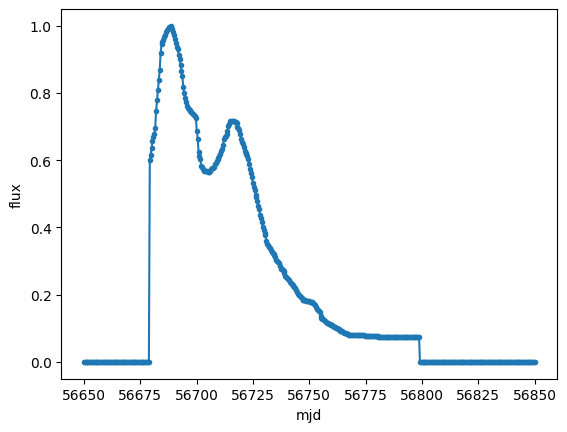

In [ ]:
t = np.linspace(56650, 56850, 500)

f = lc(t)

plt.plot(t, f, '.-')

plt.xlabel('mjd')
plt.ylabel('flux')


## Load dust image


In [ ]:
img54, header54= get_imgarr(fitsfile="dataset/LEsim/ec0915.190222.826208_ooi_i_v1_N22_140329.296582_ooi_i_v1_N22.diff.fits",
                        idx=0, return_header=True)

img_spitzer, header_spitzer= get_imgarr(fitsfile="dataset/LEsim/SPITZER_I4_12914176_0000_6_E8351909_maic.fits",
                        idx=0, return_header=True)

# project to same coordinates
img_spitzer_proj54, footprint_spitzer_proj54 = reproject_interp((img_spitzer, header_spitzer), header54)

wcs54 = astropy.wcs.WCS(header54)



In [ ]:
# cut the Spitzer image to where LEs has been observed, can use any part in the exercise

spitzer_cutout = img_spitzer_proj54[800:800+512, 3600:3600+512]

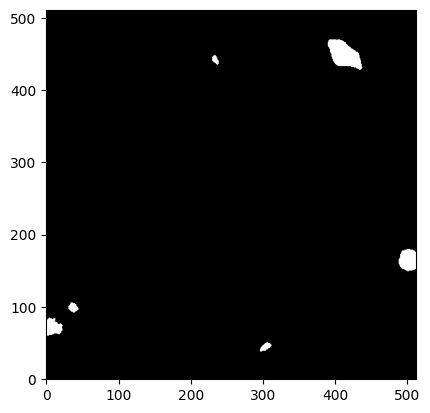

In [ ]:
# mask for stars
mask = spitzer_cutout>70
plt.imshow(mask, origin='lower', cmap='gray')

In [ ]:
# normalize the dust density

a_norm = spitzer_cutout.copy()

a_norm[a_norm>70] = 0
a_norm = a_norm/70

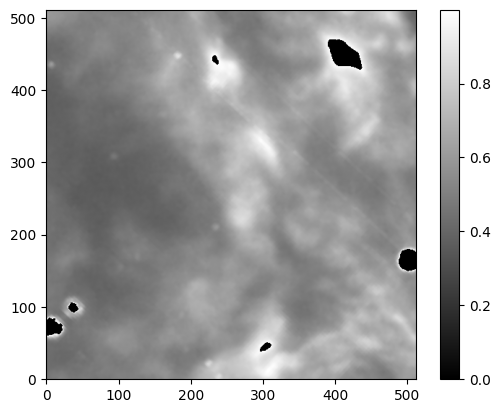

In [ ]:
plt.imshow(a_norm, origin='lower', cmap='gray')
plt.colorbar()

## compute phase difference dT

In [ ]:
(size_y, size_x) = spitzer_cutout.shape
# Create arrays for x and y
x = np.arange(size_x)
y = np.arange(size_y)

# Create a meshgrid for x and y
Y, X = np.meshgrid(y, x, indexing='ij')


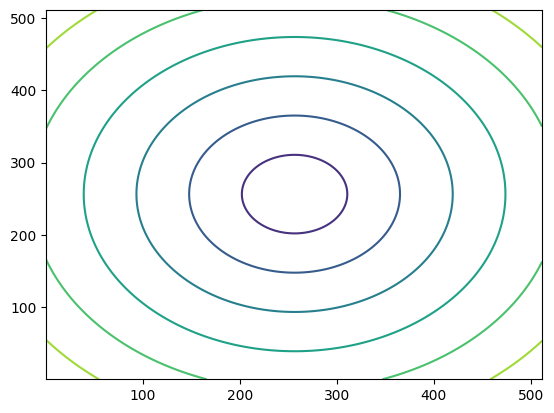

In [ ]:
#dT = np.sqrt((X+200)**2 + (Y-3000)**2) - np.sqrt((400+200)**2 + (400-3000)**2)

# the position of the source
x_source = 256
y_source = 256

dT = np.sqrt((X-x_source) ** 2 + (Y-y_source)**2)

dT = dT / dT.max()

# adjust the phase seperation
dT = dT * 100
plt.contour(dT, origin='lower',)


## create the echo image by combining dust map with the light curve model




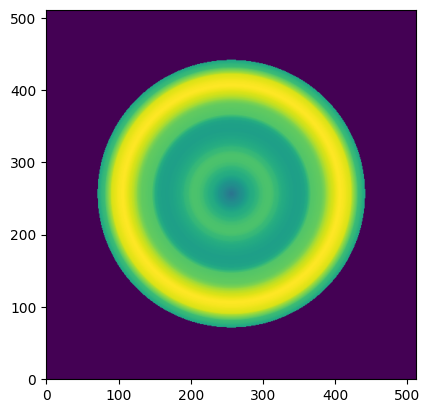

In [ ]:
T0 = 56680

plt.imshow( lc( T0 - dT + 50) , origin='lower', )


### consider dust and background

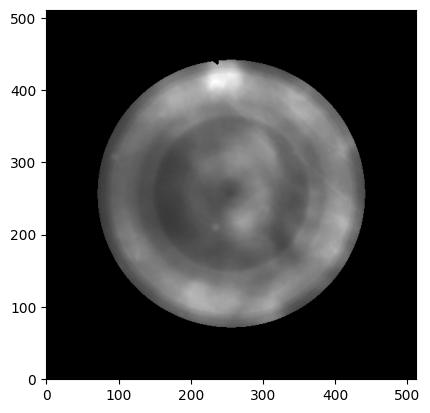

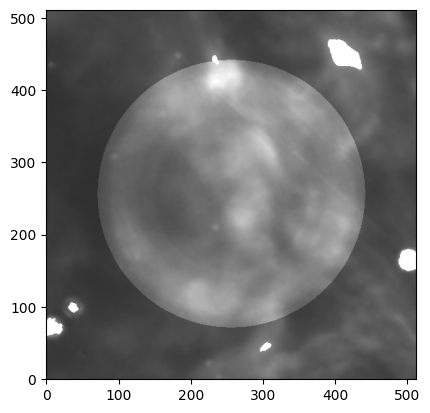

In [ ]:
# add backgrond

f_bg = a_norm * 1

# plot images
#t_tmpl = 56765  # template time

T = 50

f_le = lc( T0 - dT + T) * a_norm

f_le_bg = f_le + f_bg  # tmpl image
f_le_bg[mask] = f_le_bg.max()  # set satulated star

plt.imshow(f_le, origin='lower', vmin=0, vmax=f_le.max(), cmap='gray')

plt.figure()
plt.imshow(f_le_bg, origin='lower', vmin=0, vmax=f_le_bg.max(), cmap='gray')



## run for all time phase

In [ ]:

t = np.linspace(T0, T0+200, 500)
f = lc(t)

F_le = []
F_le_bg = []
for ti in t:
    # image
    f_le = lc(ti-dT) * a_norm
    f_le_bg = f_le + f_bg
    f_le_bg[mask] = 2#f_le_bg.max()

    #

    F_le.append(f_le)
    F_le_bg.append(f_le_bg)
    print(ti)

56680.0
56680.40080160321
56680.80160320641
56681.20240480962
56681.60320641282
56682.00400801603
56682.40480961924
56682.805611222444
56683.20641282565
56683.607214428856
56684.008016032065
56684.40881763527
56684.80961923848
56685.210420841686
56685.61122244489
56686.0120240481
56686.4128256513
56686.81362725451
56687.21442885772
56687.61523046092
56688.01603206413
56688.41683366733
56688.81763527054
56689.21843687375
56689.61923847695
56690.02004008016
56690.420841683364
56690.821643286574
56691.222444889776
56691.623246492985
56692.024048096195
56692.4248496994
56692.825651302606
56693.22645290581
56693.62725450902
56694.02805611223
56694.42885771543
56694.82965931864
56695.23046092184
56695.63126252505
56696.03206412826
56696.43286573146
56696.83366733467
56697.23446893787
56697.63527054108
56698.03607214429
56698.436873747494
56698.837675350704
56699.238476953906
56699.639278557115
56700.04008016032
56700.44088176353
56700.841683366736
56701.24248496994
56701.64328657315
56702.04

In [ ]:
F_le_stack = np.stack(F_le, axis=-1)
F_le_bg_stack = np.stack(F_le_bg, axis=-1)

In [ ]:
F_le_stack.shape

(512, 512, 500)

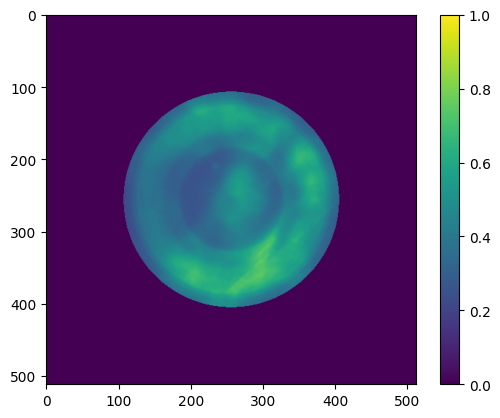

In [ ]:
t = 100
plt.imshow(F_le_stack[:, :, t], vmin=0, vmax=1.)
plt.colorbar()

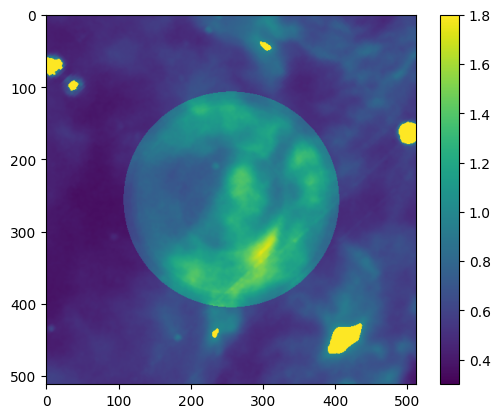

In [ ]:
plt.imshow(F_le_bg_stack[:, :, t], vmin=0.3, vmax=1.8)
plt.colorbar()

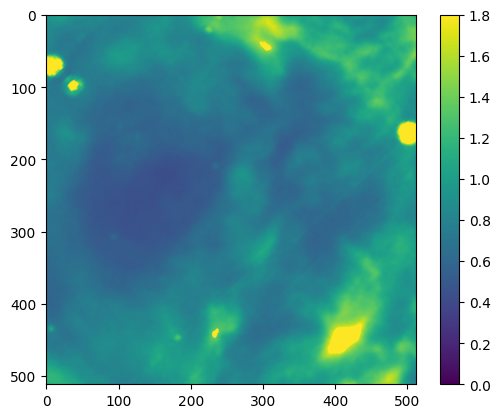

In [ ]:
plt.imshow(F_le_bg_stack[:, :, 260], vmin=0, vmax=1.8)
plt.colorbar()

**Exercise: make an animation shows the simulated light echoes**

In [ ]:
def animate(nframe, ):
    """animate the data
     """
    fig.clear()
    ax = fig.add_subplot(121)


    im = ax.imshow(F_le_bg_stack[:, :, nframe], vmin=0.3, vmax=1.8)

    ax.set_xticks([]);
    ax.set_yticks([]);

    ax = fig.add_subplot(122)

    im = ax.imshow(F_le_stack[:, :, nframe], vmin=0., vmax=1.)
    ax.set_xticks([]);
    ax.set_yticks([]);

    print(f'nframe {nframe}')
    return fig


nframe 0


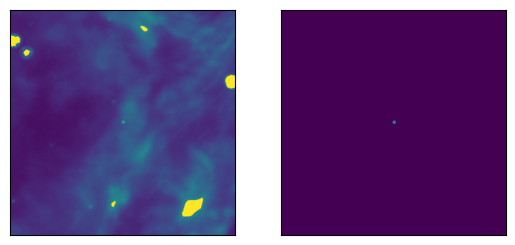

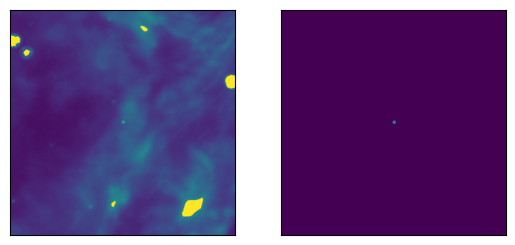

In [ ]:
fig = plt.figure()
animate(0)

In [ ]:
import matplotlib.animation as animation


In [ ]:
%%time
anim = animation.FuncAnimation(fig, animate, fargs=(), frames=499 )#interval=100, )

anim.save('./dataset/LEsim/ec.mp4', writer=animation.FFMpegWriter(fps=20) )


nframe 0
nframe 0
nframe 1
nframe 2
nframe 3
nframe 4
nframe 5
nframe 6
nframe 7
nframe 8
nframe 9
nframe 10
nframe 11
nframe 12
nframe 13
nframe 14
nframe 15
nframe 16
nframe 17
nframe 18
nframe 19
nframe 20
nframe 21
nframe 22
nframe 23
nframe 24
nframe 25
nframe 26
nframe 27
nframe 28
nframe 29
nframe 30
nframe 31
nframe 32
nframe 33
nframe 34
nframe 35
nframe 36
nframe 37
nframe 38
nframe 39
nframe 40
nframe 41
nframe 42
nframe 43
nframe 44
nframe 45
nframe 46
nframe 47
nframe 48
nframe 49
nframe 50
nframe 51
nframe 52
nframe 53
nframe 54
nframe 55
nframe 56
nframe 57
nframe 58
nframe 59
nframe 60
nframe 61
nframe 62
nframe 63
nframe 64
nframe 65
nframe 66
nframe 67
nframe 68
nframe 69
nframe 70
nframe 71
nframe 72
nframe 73
nframe 74
nframe 75
nframe 76
nframe 77
nframe 78
nframe 79
nframe 80
nframe 81
nframe 82
nframe 83
nframe 84
nframe 85
nframe 86
nframe 87
nframe 88
nframe 89
nframe 90
nframe 91
nframe 92
nframe 93
nframe 94
nframe 95
nframe 96
nframe 97
nframe 98
nframe 99
n

In [ ]:
# save the simulated sequences for future use
np.savez("./dataset/LEsim/LEsim_sn2014J.npz", spitzer_cutout=spitzer_cutout, f_bg=f_bg, F_le_stack=F_le_stack)



**Exercise: extract the light curves at two different locations, how are they related**

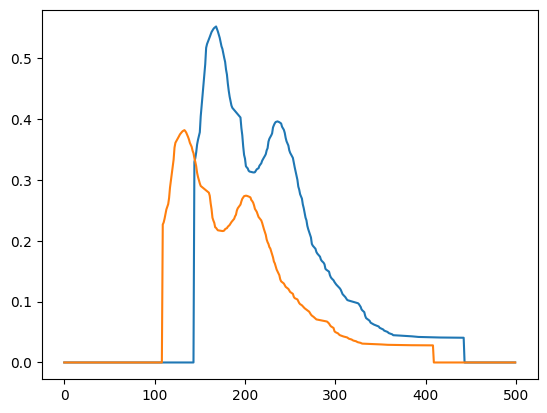

In [ ]:
x_pix = 400
y_pix = 100
lc_pix = F_le_stack[y_pix, x_pix, :]

plt.plot(lc_pix)

x_pix = 100
y_pix = 300
lc_pix = F_le_stack[y_pix, x_pix, :]

plt.plot(lc_pix)

**Exercise: can we get the light curve from single phase image?**

In [ ]:
# implement here



**change the time scale of the transient, how the appearance of the LEs changes for short and long transients**